# Intro

$x_t$ is a single video frame (image at time t)

$$
z_t = f_{\theta}(x_t)
$$

$f_{\theta}$ = CNN encoder (neural network with parameters $\theta$)  
*Input:* image $x_t$  
*Output:* latent vector $z_t$ (compressed numeric representation of the frame)

$$
z_{t+1} = f_{\theta}(x_{t+1})
$$

Same CNN encoder  
*Input:* next image $x_{t+1}$  
*Output:* true next latent representation $z_{t+1}$

$$
\hat{a}_t = g_{\phi}(z_t, z_{t+1})
$$

$g_{\phi}$ = Action Inference Network (MLP with parameters $\phi$)  
*Input:* current latent $z_t$ and next latent $z_{t+1}$  
*Output:* inferred action $\hat{a}_t$ that best explains transition

$$
\hat{z}_{t+1} = h_{\psi}(z_t, \hat{a}_t)
$$

$h_{\psi}$ = Dynamics model (MLP or RNN with parameters $\psi$)  
*Input:* current latent $z_t$ and inferred action $\hat{a}_t$  
*Output:* predicted next latent $\hat{z}_{t+1}$

$$
\hat{x}_{t+1} = d_{\omega}(\hat{z}_{t+1})
$$

$d_{\omega}$ = Decoder network (neural network with parameters $\omega$)  
*Input:* predicted latent $\hat{z}_{t+1}$  
*Output:* predicted next image $\hat{x}_{t+1}$

$$
L_{pixel} = \| x_{t+1} - \hat{x}_{t+1} \|^2
$$

Pixel reconstruction loss (MSE)  
*Input:* true frame $x_{t+1}$ and predicted frame $\hat{x}_{t+1}$  
*Output:* scalar reconstruction error

$$
L_{latent} = \| z_{t+1} - \hat{z}_{t+1} \|^2
$$

Latent consistency loss (MSE)
*Input:* true latent $z_{t+1}$ and predicted latent $\hat{z}_{t+1}$  
*Output:* scalar latent error

$$
L = L_{pixel} + \alpha L_{latent}
$$

Total training loss minimized during learning

# Data

In [1]:
VIDEO_DIR = "../Donor/videos"

## Download Data

In [1]:
import cv2
import numpy as np

path = "../Donor/videos/rl-video-episode-0.mp4"

cap = cv2.VideoCapture(path)

frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # BGR -> RGB (ważne)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # resize
    frame = cv2.resize(frame, (84, 84))

    # normalize + float32
    frame = frame.astype(np.float32) / 255.0

    # (H,W,C) -> (C,H,W)
    frame = np.transpose(frame, (2, 0, 1))

    frames.append(frame)

cap.release()

# sanity check
print(len(frames), frames[0].shape)

907 (3, 84, 84)


(np.float64(-0.5), np.float64(83.5), np.float64(83.5), np.float64(-0.5))

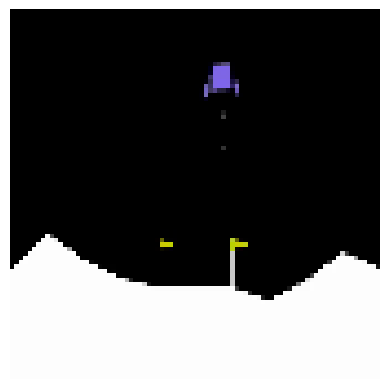

In [20]:
# import matplotlib.pyplot as plt
transposition = (1,2,0)

plt.imshow(frames[45].transpose(transposition))
plt.axis(False)

## Dataset

## DataLoader